In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [3]:
df=df.drop(['day','month','year'],axis=1)

In [4]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [5]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [6]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [7]:
#Creating independent and dependent features
X = df.drop('FWI',axis=1)
y = df['FWI']

In [8]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [9]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [10]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

In [11]:
#Feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.620929,-0.271423,-0.307315,0.643923,0.491119,0.361489,0.577606,0.457320,0.512162,0.278739
RH,-0.620929,1.000000,0.181966,0.221883,-0.622897,-0.373911,-0.190387,-0.662801,-0.316040,-0.395287,-0.412307
Ws,-0.271423,0.181966,1.000000,0.195423,-0.107585,0.037273,0.122497,0.076060,0.069537,-0.037045,-0.226819
Rain,-0.307315,0.221883,0.195423,1.000000,-0.544467,-0.304522,-0.315069,-0.355279,-0.314369,-0.415752,-0.042312
FFMC,0.643923,-0.622897,-0.107585,-0.544467,1.000000,0.623587,0.523127,0.742285,0.605418,0.783103,0.242648
DMC,0.491119,-0.373911,0.037273,-0.304522,0.623587,1.000000,0.876578,0.684122,0.983270,0.625013,0.174263
DC,0.361489,-0.190387,0.122497,-0.315069,0.523127,0.876578,1.000000,0.513990,0.947854,0.560104,-0.096635
ISI,0.577606,-0.662801,0.076060,-0.355279,0.742285,0.684122,0.513990,1.000000,0.639526,0.729911,0.284786
BUI,0.457320,-0.316040,0.069537,-0.314369,0.605418,0.983270,0.947854,0.639526,1.000000,0.618355,0.073493
Classes,0.512162,-0.395287,-0.037045,-0.415752,0.783103,0.625013,0.560104,0.729911,0.618355,1.000000,0.209863


<Axes: >

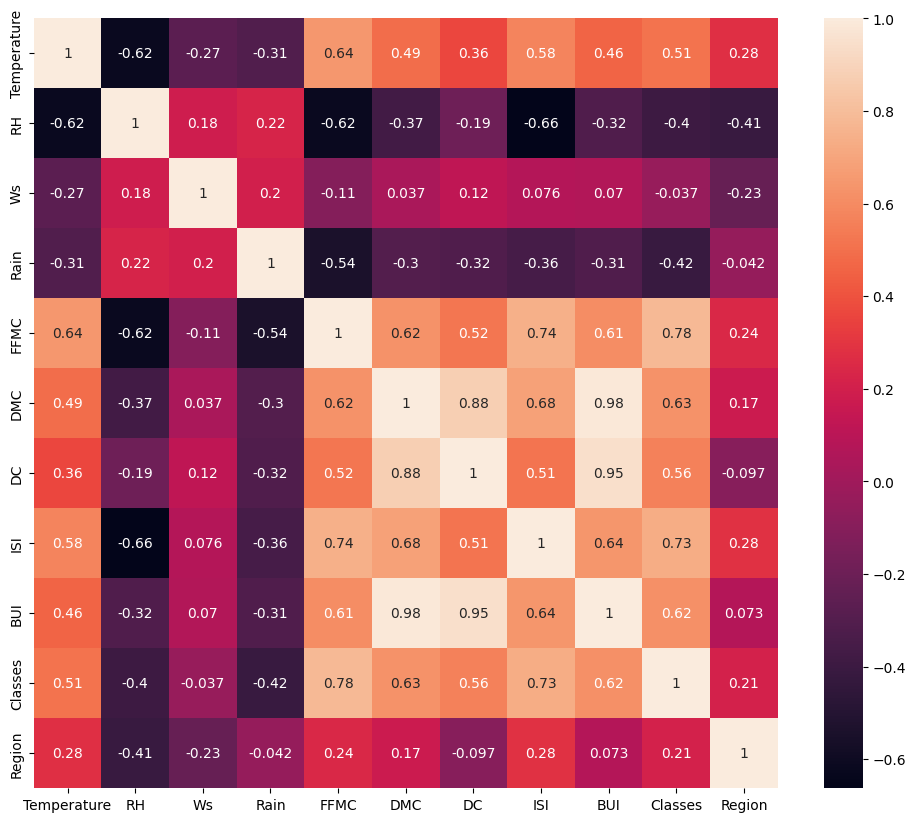

In [12]:
##Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(X_train.corr(),annot=True)

In [13]:
def correlation(dataset,threshold):
  col_corr=set()
  corr_matrix= dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j])>threshold:
        colname = corr_matrix.columns[i]
        col_corr.add(colname)
  return col_corr

In [14]:
#Threshold
corr_features= correlation(X_train,0.85)

In [15]:
#Drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

#Feature Scaling or Standardization

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [17]:
X_train_scaled

array([[ 5.24210595e-01, -1.48874108e+00,  9.46809887e-01, ...,
         2.29764065e+00,  8.46747384e-01,  9.89070710e-01],
       [ 2.41943352e-01,  5.60295042e-01,  5.77817597e-01, ...,
         9.45766517e-02,  8.46747384e-01, -1.01105006e+00],
       [ 1.65327957e+00, -1.28383747e+00, -8.98151563e-01, ...,
        -1.71727788e-01,  8.46747384e-01,  9.89070710e-01],
       ...,
       [ 1.08874508e+00, -2.59319406e-01,  1.31580218e+00, ...,
         1.06295643e+00,  8.46747384e-01, -1.01105006e+00],
       [-1.73392735e+00,  1.31160829e+00,  1.31580218e+00, ...,
        -2.26132641e-03,  8.46747384e-01, -1.01105006e+00],
       [-8.87125622e-01,  7.65198654e-01,  5.77817597e-01, ...,
        -8.25384141e-01, -1.18098977e+00, -1.01105006e+00]])

#Box plots to understand effect of standard scaler


Text(0.5, 1.0, 'X_train After Scaling')

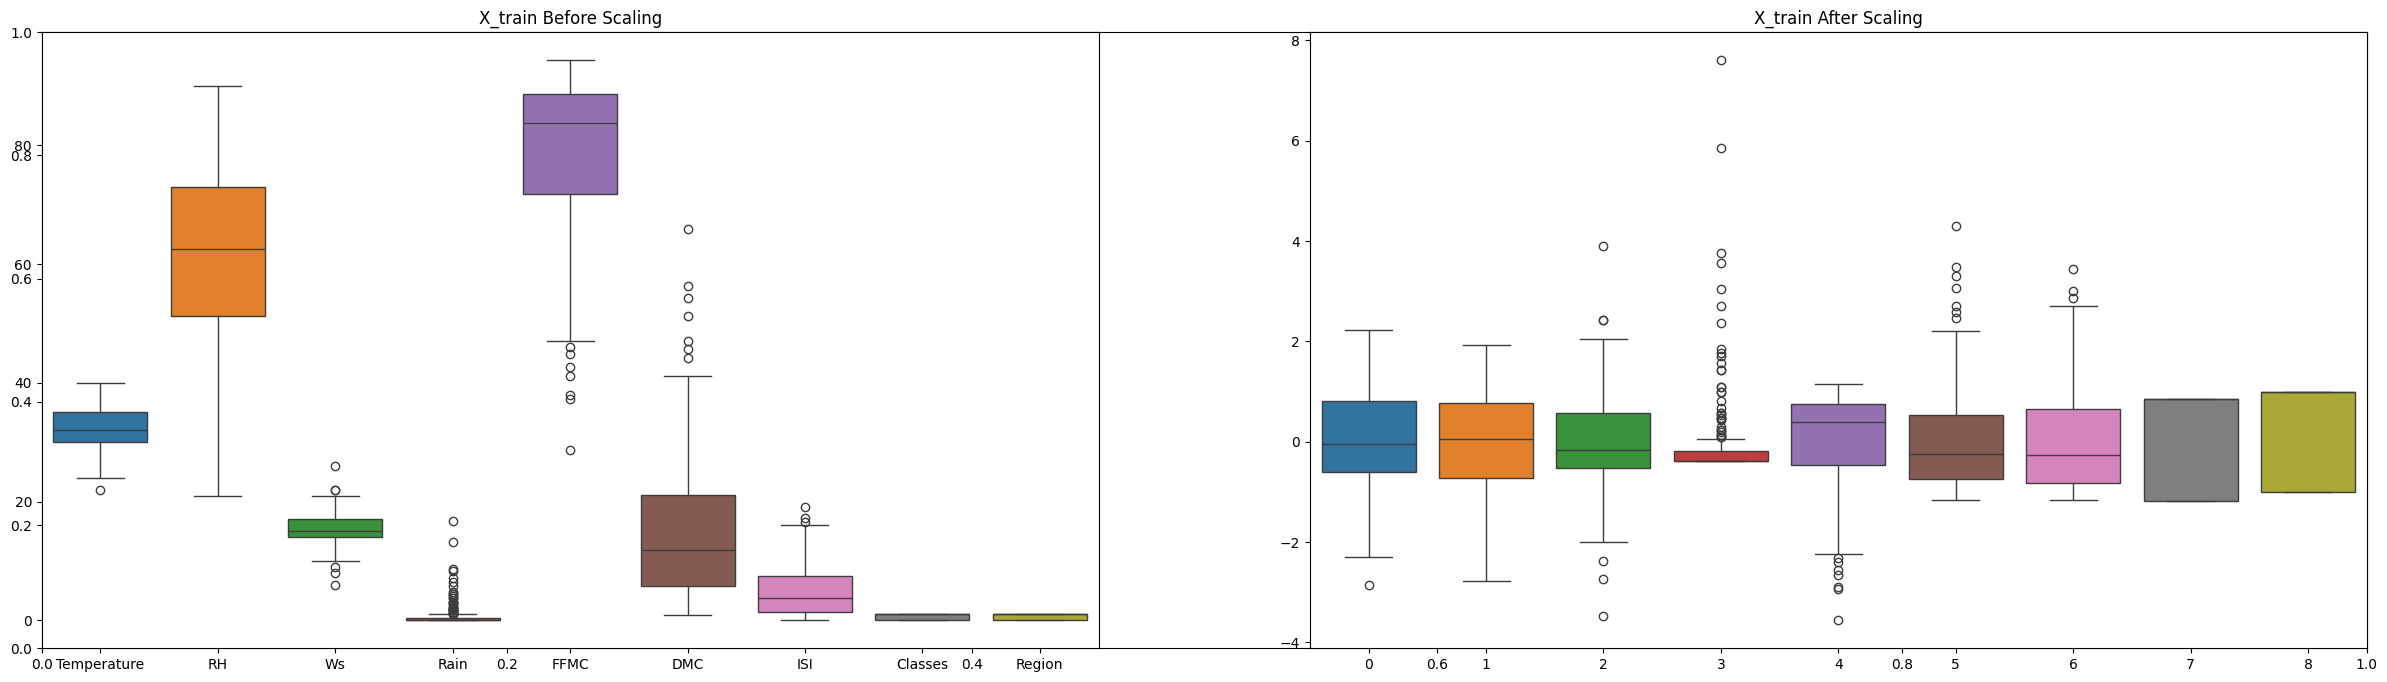

In [18]:
plt.subplots(figsize=(30,8))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

#Linear Regression Model

Mean absolute error 0.6740104768855226
R2 score 0.9840540762337815


Text(0, 0.5, 'Predicted')

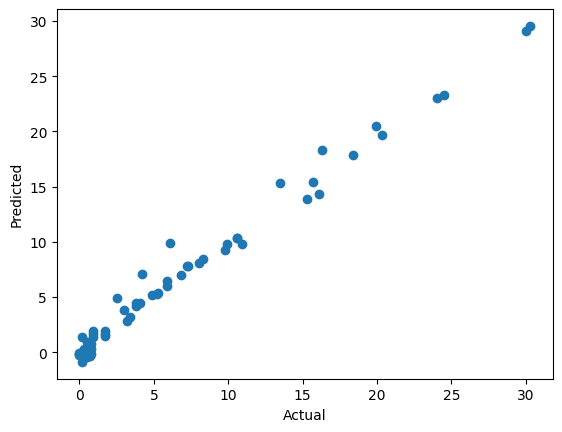

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

#Lasso Regression

Mean absolute error 1.3231024563212943
R2 score 0.9508643136202581


Text(0, 0.5, 'Predicted')

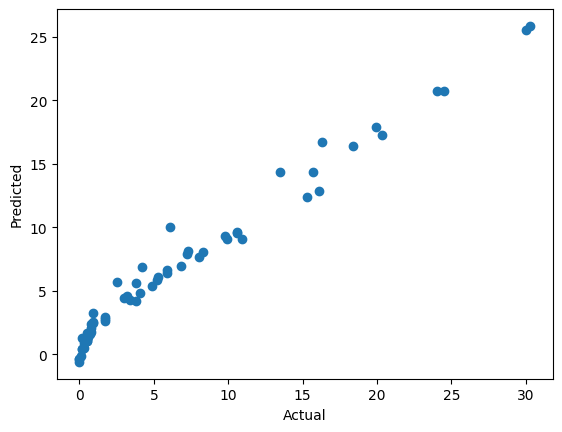

In [20]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error,r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

#Cross Validation Lasso

In [23]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error,r2_score
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

In [26]:
#Checking the alpha value that was chosen
lassocv.alpha_

np.float64(0.0383414997377244)

Mean absolute error 0.7204939069953782
R2 score 0.9828532604384133


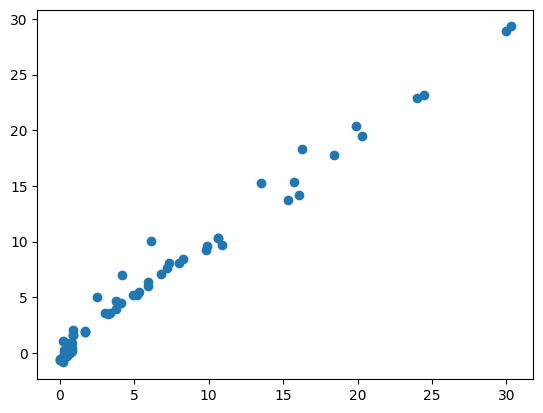

In [28]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test, y_pred)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)

#Ridge Regression

Mean absolute error 0.6958390999989531
R2 score 0.9836316111671296


Text(0, 0.5, 'Predicted')

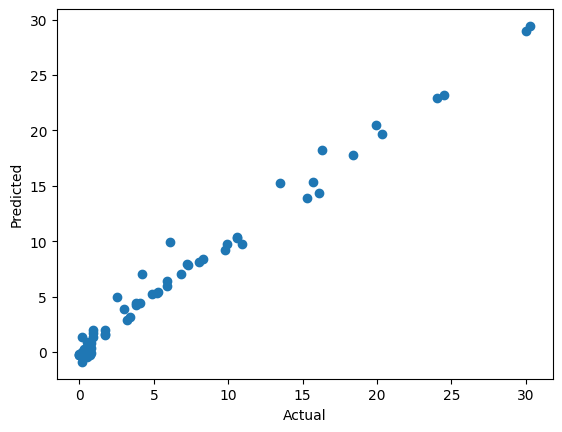

In [21]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

#Cross Validation Ridge

Mean absolute error 0.6958390999989531
R2 score 0.9836316111671296


Text(0, 0.5, 'Predicted')

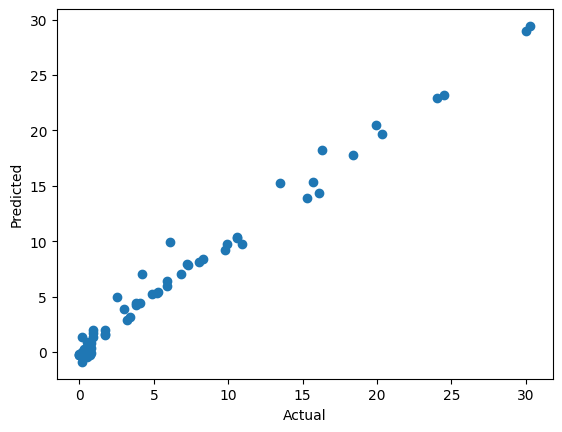

In [30]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

#Elasticnet Regression

Mean absolute error 1.9072342624620537
R2 score 0.8912817791829821


Text(0, 0.5, 'Predicted')

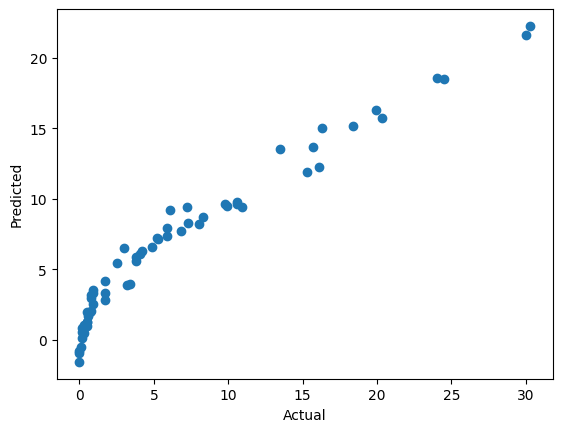

In [22]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

#Cross validation ElasticNet

Mean absolute error 0.7341884119415886
R2 score 0.9827054499337484


Text(0, 0.5, 'Predicted')

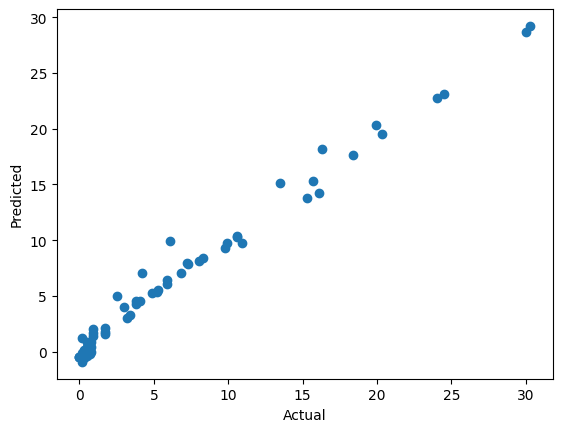

In [31]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error,r2_score
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
mae= mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 score",score)
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')